In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import Values_at_Risk_predictor.data_loader
import Values_at_Risk_predictor.GARCH_Engine
import Values_at_Risk_predictor.backtest

/home/home/miniconda3/envs/MathModelling/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Data Preparations

[*********************100%***********************]  1 of 1 completed


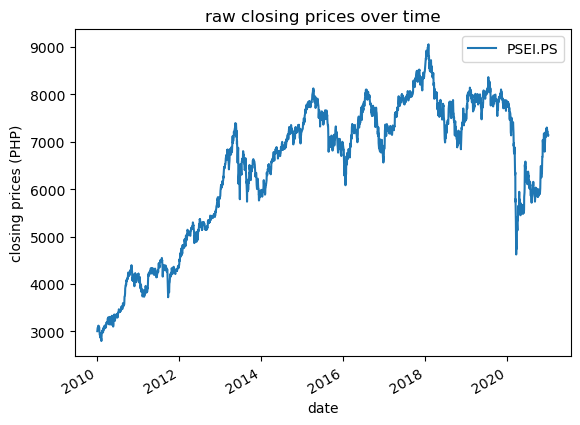

In [2]:
predictor = Values_at_Risk_predictor.data_loader.DataLoader()
datas = predictor.load_data()

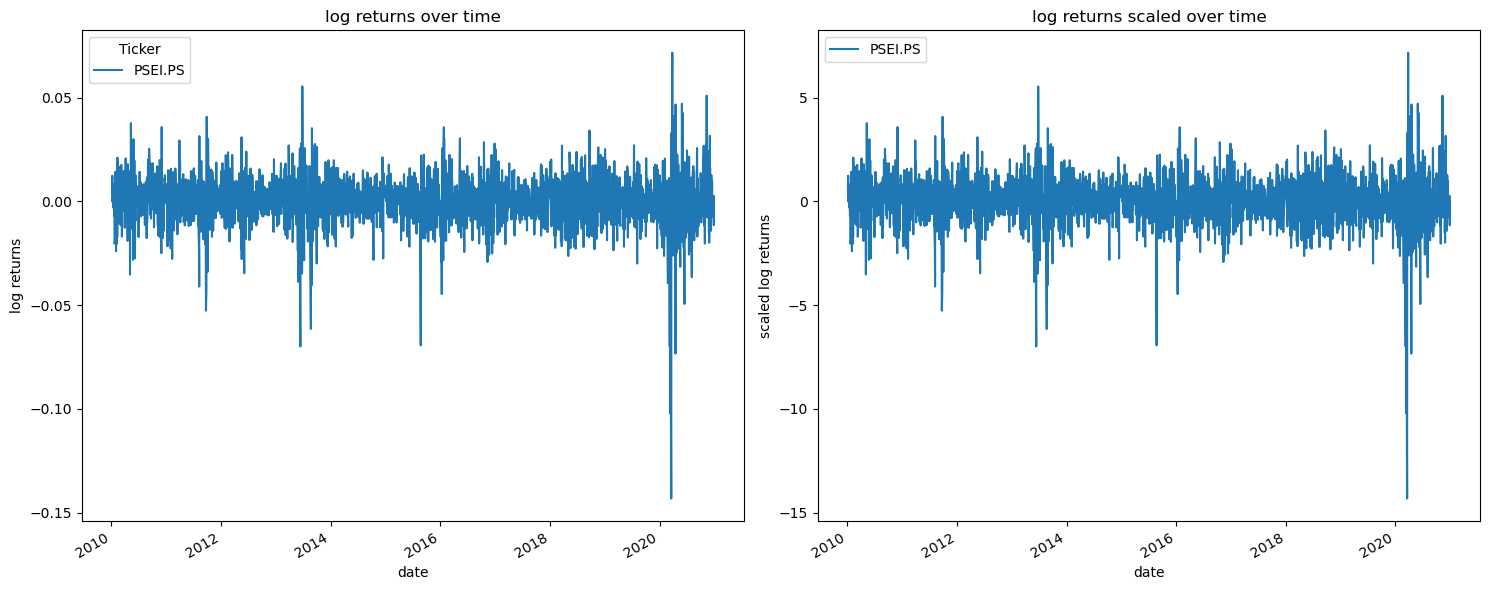

In [3]:
log_returns, log_returns_scaled = predictor.compute_returns()

In [4]:
diagnostics = predictor.vitals()
diagnostics

(Ticker
 PSEI.PS    0.032397
 dtype: float64,
 Ticker
 PSEI.PS    1.188576
 dtype: float64,
 Ticker
 PSEI.PS   -1.289341
 dtype: float64,
 Ticker
 PSEI.PS    14.144085
 dtype: float64)

GARCH(1,1)

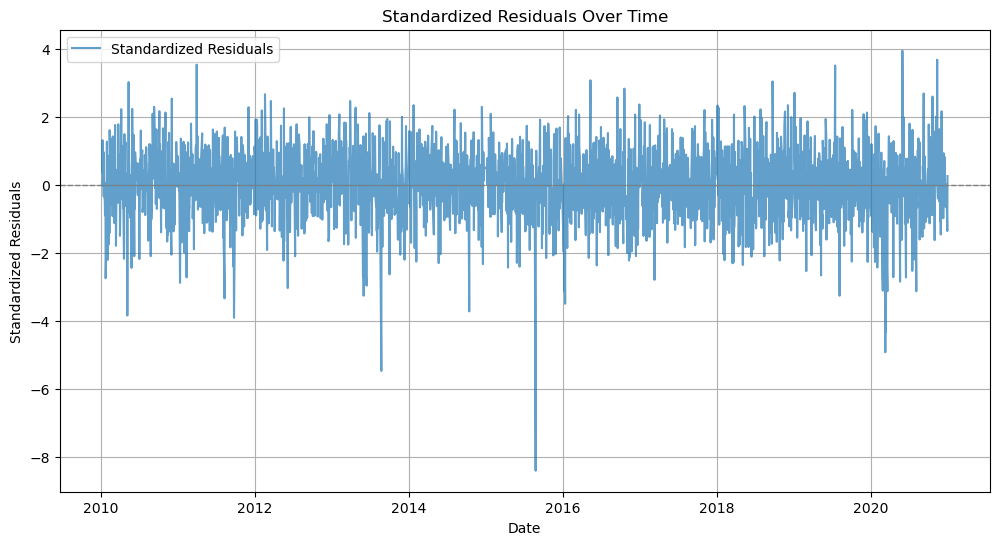

In [5]:
garch_engine = Values_at_Risk_predictor.GARCH_Engine.GARCHEngine(log_returns=log_returns_scaled)
garch_engine.garch_engine()

In [6]:
garch_engine.vitals()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             Zero Mean - GARCH Model Results                             
=========================================================================================
Dep. Variable:                           PSEI.PS   R-squared:                       0.000
Mean Model:                            Zero Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -3822.40
Distribution:      Standardized Skew Student's t   AIC:                           7654.79
Method:                       Maximum Likelihood   BIC:                           7684.24
                                                   No. Observations:                 2672
Date:                           Thu, Apr 16 2026   Df Residuals:                     2672
Time:                                   06:59:15   Df Model:                            0
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0613  1.522e-02      4.027  5.639e-05 [3.147e-02,9.115e-02]
alpha[1]       0.1267  1.985e-02      6.381  1.759e-10   [8.775e-02,  0.166]
beta[1]        0.8268  2.589e-02     31.930 1.019e-223     [  0.776,  0.878]
                                Distribution                               
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
eta            7.9191      1.231      6.431  1.271e-10    [  5.505, 10.333]
lambda        -0.1111  2.605e-02     -4.265  1.997e-05 [ -0.162,-6.006e-02]
===========================================================================

Covariance estimator: robust
"""

In [7]:
VaR = garch_engine.compute_VaR()
VaR

Date
2010-01-05    1.607411
2010-01-06    1.579512
2010-01-07    1.506418
2010-01-08    1.593856
2010-01-11    1.503314
                ...   
2020-12-22    1.605464
2020-12-23    1.524007
2020-12-24    1.442231
2020-12-28    1.370852
2020-12-29    1.465093
Name: cond_vol, Length: 2672, dtype: float64

In [9]:
garch_engine.visuals_extentsion()

AttributeError: Axes.set() got an unexpected keyword argument 'figsize'

<Figure size 640x480 with 0 Axes>

In [ ]:
backtester = Values_at_Risk_predictor.backtest.Backtest(log_returns_scaled, VaR, 0.05)
backtester.backtest()

Violation rate: 0.0502 (expected 0.05)


In [ ]:
backtester.kupiec_test()

(np.float64(-531.5584153199052),
 np.float64(-531.5592125174505),
 np.float64(0.0015943950907058024),
 np.float64(0.9681490315551277))

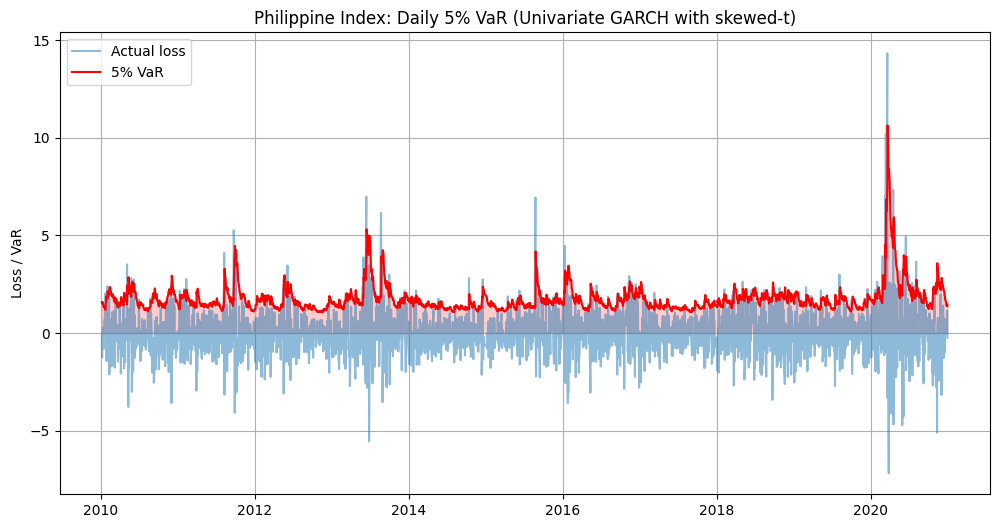

In [ ]:
backtester.visualize_VaR()

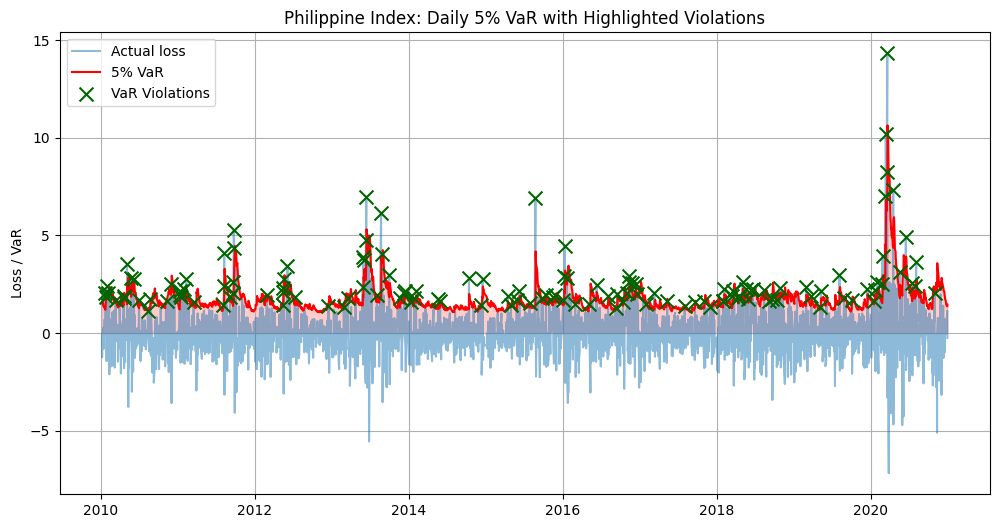

In [ ]:
backtester.visuals_extension()

In [ ]:
backtester.visualize_returns()